In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

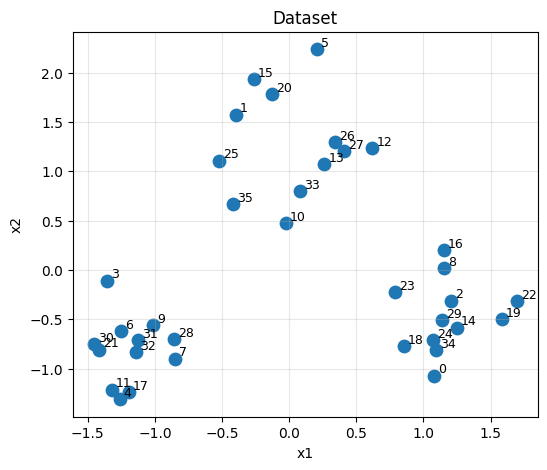

In [ ]:
X, y_true = make_blobs(
    n_samples=36,
    centers=[(-2, -1), (0.5, 2.0), (2.5, -0.5)],
    cluster_std=[0.45, 0.55, 0.50],
    random_state=7
)

X = StandardScaler().fit_transform(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=80)
for i, (x1, x2) in enumerate(X):
    plt.text(x1 + 0.03, x2 + 0.03, str(i), fontsize=9)
plt.title("Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
def euclidean(a, b):
    return np.linalg.norm(a - b)


def cluster_centroid(X, cluster):
    pts = X[list(cluster)]
    return pts.mean(axis=0)


def cluster_sse(X, cluster):
    pts = X[list(cluster)]
    mu = pts.mean(axis=0)
    return np.sum((pts - mu) ** 2)


def cluster_distance(X, cluster_a, cluster_b, linkage="single"):
    pts_a = X[list(cluster_a)]
    pts_b = X[list(cluster_b)]

    pairwise = np.linalg.norm(pts_a[:, None, :] - pts_b[None, :, :], axis=2)

    if linkage == "single":
        return np.min(pairwise)

    if linkage == "complete":
        return np.max(pairwise)

    if linkage == "average":
        return np.mean(pairwise)

    if linkage == "ward":
        union = cluster_a | cluster_b
        return cluster_sse(X, union) - cluster_sse(X, cluster_a) - cluster_sse(X, cluster_b)

    raise ValueError("linkage no reconocido")

## Agglomerative approach

In [ ]:
def agglomerative_clustering(X, linkage="single"):
    n = len(X)
    clusters = [{i} for i in range(n)]
    history = []

    while len(clusters) > 1:
        best_i, best_j = None, None
        best_dist = np.inf

        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                d = cluster_distance(X, clusters[i], clusters[j], linkage=linkage)
                if d < best_dist:
                    best_dist = d
                    best_i, best_j = i, j

        A = clusters[best_i]
        B = clusters[best_j]
        merged = A | B

        history.append({
            "cluster_a": sorted(A),
            "cluster_b": sorted(B),
            "distance": best_dist,
            "merged": sorted(merged),
            "n_clusters_after_merge": len(clusters) - 1
        })

        new_clusters = []
        for k, c in enumerate(clusters):
            if k not in (best_i, best_j):
                new_clusters.append(c)
        new_clusters.append(merged)

        clusters = new_clusters

    return history

In [ ]:
history_single = agglomerative_clustering(X, linkage="single")

for step, h in enumerate(history_single, start=1):
    print(f"Paso {step}")
    print(f"  cluster_a = {h['cluster_a']}")
    print(f"  cluster_b = {h['cluster_b']}")
    print(f"  distance  = {h['distance']:.4f}")
    print(f"  merged    = {h['merged']}")
    print(f"  clusters restantes = {h['n_clusters_after_merge']}")
    print()

Paso 1
  cluster_a = [21]
  cluster_b = [30]
  distance  = 0.0681
  merged    = [21, 30]
  clusters restantes = 35

Paso 2
  cluster_a = [4]
  cluster_b = [17]
  distance  = 0.0988
  merged    = [4, 17]
  clusters restantes = 34

Paso 3
  cluster_a = [24]
  cluster_b = [34]
  distance  = 0.1049
  merged    = [24, 34]
  clusters restantes = 33

Paso 4
  cluster_a = [26]
  cluster_b = [27]
  distance  = 0.1109
  merged    = [26, 27]
  clusters restantes = 32

Paso 5
  cluster_a = [11]
  cluster_b = [4, 17]
  distance  = 0.1125
  merged    = [4, 11, 17]
  clusters restantes = 31

Paso 6
  cluster_a = [31]
  cluster_b = [32]
  distance  = 0.1230
  merged    = [31, 32]
  clusters restantes = 30

Paso 7
  cluster_a = [14]
  cluster_b = [29]
  distance  = 0.1327
  merged    = [14, 29]
  clusters restantes = 29

Paso 8
  cluster_a = [6]
  cluster_b = [31, 32]
  distance  = 0.1559
  merged    = [6, 31, 32]
  clusters restantes = 28

Paso 9
  cluster_a = [8]
  cluster_b = [16]
  distance  = 0.17

#### Número fijo de clusters

In [ ]:
def agglomerative_until_k(X, k=3, linkage="single"):
    n = len(X)
    clusters = [{i} for i in range(n)]

    while len(clusters) > k:
        best_i, best_j = None, None
        best_dist = np.inf

        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                d = cluster_distance(X, clusters[i], clusters[j], linkage=linkage)
                if d < best_dist:
                    best_dist = d
                    best_i = i
                    best_j = j

        merged = clusters[best_i] | clusters[best_j]

        new_clusters = []
        for idx, c in enumerate(clusters):
            if idx not in (best_i, best_j):
                new_clusters.append(c)
        new_clusters.append(merged)

        clusters = new_clusters

    labels = np.empty(n, dtype=int)
    for label, cluster in enumerate(clusters):
        for idx in cluster:
            labels[idx] = label

    return labels, clusters

In [ ]:
def plot_clusters(X, labels, title):
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=labels, s=90, cmap="tab10")
    for i, (x1, x2) in enumerate(X):
        plt.text(x1 + 0.03, x2 + 0.03, str(i), fontsize=9)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(alpha=0.3)
    plt.show()

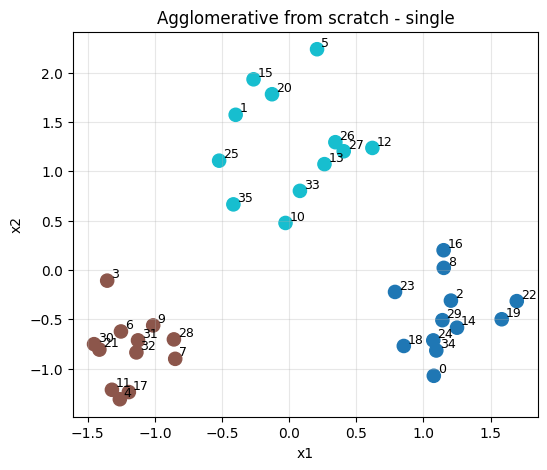

single: [[0, 2, 8, 14, 16, 18, 19, 22, 23, 24, 29, 34], [3, 4, 6, 7, 9, 11, 17, 21, 28, 30, 31, 32], [1, 5, 10, 12, 13, 15, 20, 25, 26, 27, 33, 35]]



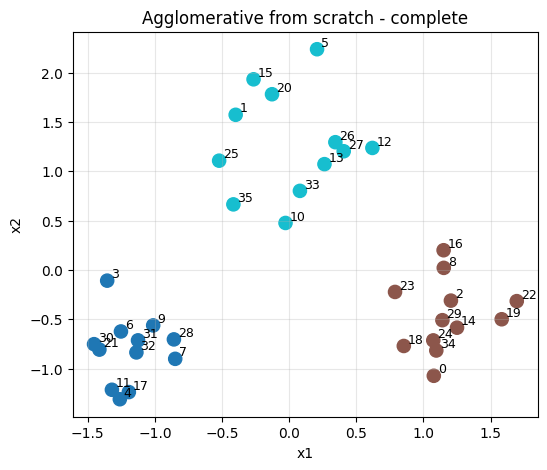

complete: [[3, 4, 6, 7, 9, 11, 17, 21, 28, 30, 31, 32], [0, 2, 8, 14, 16, 18, 19, 22, 23, 24, 29, 34], [1, 5, 10, 12, 13, 15, 20, 25, 26, 27, 33, 35]]



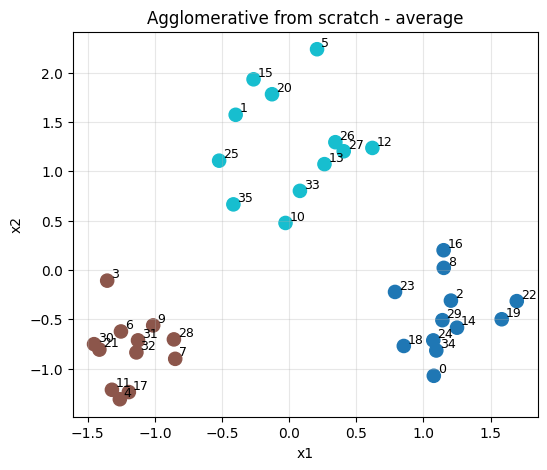

average: [[0, 2, 8, 14, 16, 18, 19, 22, 23, 24, 29, 34], [3, 4, 6, 7, 9, 11, 17, 21, 28, 30, 31, 32], [1, 5, 10, 12, 13, 15, 20, 25, 26, 27, 33, 35]]



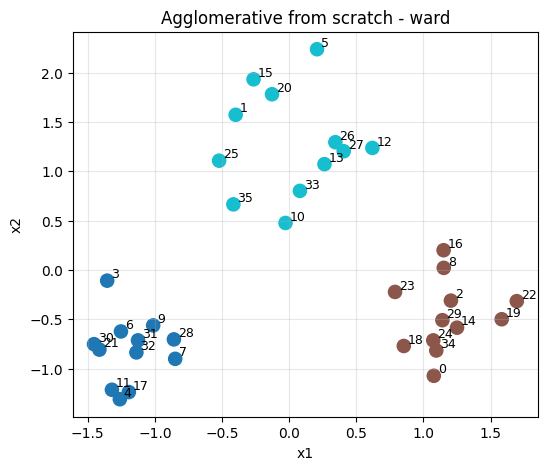

ward: [[3, 4, 6, 7, 9, 11, 17, 21, 28, 30, 31, 32], [0, 2, 8, 14, 16, 18, 19, 22, 23, 24, 29, 34], [1, 5, 10, 12, 13, 15, 20, 25, 26, 27, 33, 35]]



In [ ]:
for linkage in ["single", "complete", "average", "ward"]:
    labels, clusters = agglomerative_until_k(X, k=3, linkage=linkage)
    plot_clusters(X, labels, title=f"Agglomerative from scratch - {linkage}")
    print(f"{linkage}: {list(map(sorted, clusters))}")
    print()

In [ ]:
def plot_agglomerative_steps(X, linkage="single", max_steps=8):
    n = len(X)
    clusters = [{i} for i in range(n)]

    steps_to_plot = min(max_steps, n - 1)
    fig, axes = plt.subplots(2, int(np.ceil(steps_to_plot / 2)), figsize=(15, 7))
    axes = np.array(axes).reshape(-1)

    for step in range(steps_to_plot):
        best_i, best_j = None, None
        best_dist = np.inf

        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                d = cluster_distance(X, clusters[i], clusters[j], linkage=linkage)
                if d < best_dist:
                    best_dist = d
                    best_i = i
                    best_j = j

        A = clusters[best_i]
        B = clusters[best_j]

        labels = np.full(n, -1)
        for label, cluster in enumerate(clusters):
            for idx in cluster:
                labels[idx] = label

        ax = axes[step]
        ax.scatter(X[:, 0], X[:, 1], c=labels, s=90, cmap="tab20")
        ax.scatter(X[list(A), 0], X[list(A), 1], s=160, marker="o", facecolors="none")
        ax.scatter(X[list(B), 0], X[list(B), 1], s=160, marker="s", facecolors="none")

        for i, (x1, x2) in enumerate(X):
            ax.text(x1 + 0.03, x2 + 0.03, str(i), fontsize=8)

        ax.set_title(
            f"Paso {step+1}\nmerge {sorted(A)} + {sorted(B)}\nd={best_dist:.3f}"
        )
        ax.grid(alpha=0.3)

        merged = A | B
        new_clusters = []
        for idx, c in enumerate(clusters):
            if idx not in (best_i, best_j):
                new_clusters.append(c)
        new_clusters.append(merged)
        clusters = new_clusters

    for ax in axes[steps_to_plot:]:
        ax.axis("off")

    fig.suptitle(f"Agglomerative clustering ({linkage})", fontsize=16)
    plt.tight_layout()
    plt.show()

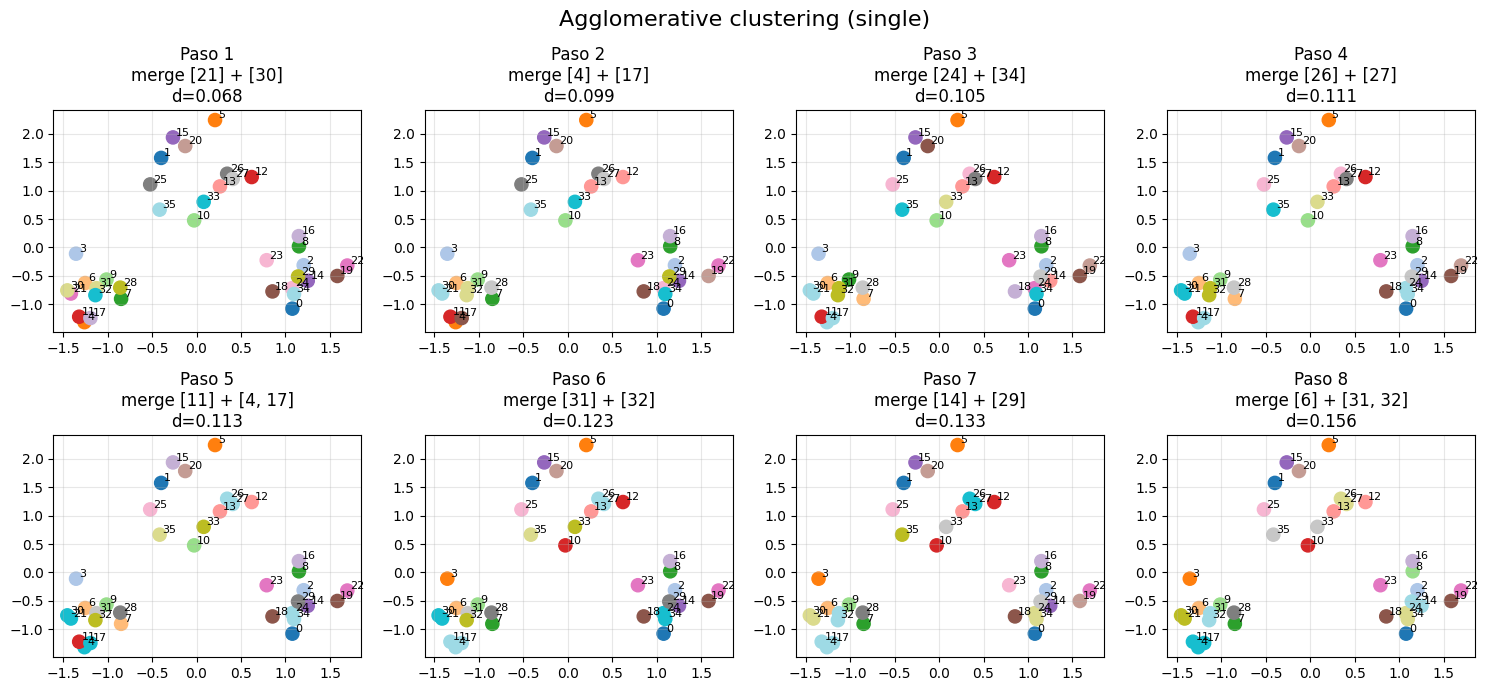

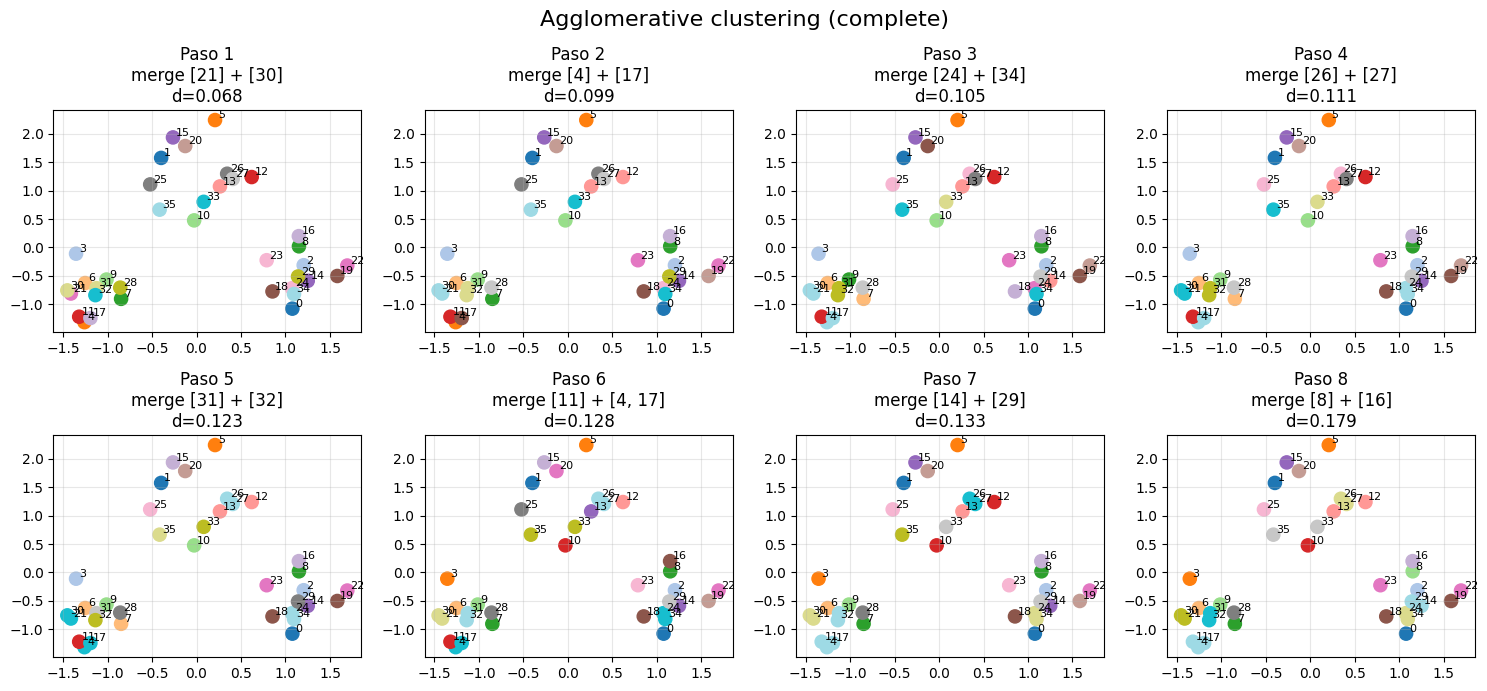

In [ ]:
plot_agglomerative_steps(X, linkage="single", max_steps=8)
plot_agglomerative_steps(X, linkage="complete", max_steps=8)

## Dendrograma

In [ ]:
from scipy.cluster.hierarchy import dendrogram

In [ ]:
def agglomerative_linkage_matrix(X, linkage="single"):
    n = len(X)

    active_clusters = {i: {i} for i in range(n)}
    sizes = {i: 1 for i in range(n)}
    next_cluster_id = n
    Z = []

    while len(active_clusters) > 1:
        keys = list(active_clusters.keys())
        best_a, best_b = None, None
        best_dist = np.inf

        for i in range(len(keys)):
            for j in range(i + 1, len(keys)):
                a_id, b_id = keys[i], keys[j]
                A = active_clusters[a_id]
                B = active_clusters[b_id]
                d = cluster_distance(X, A, B, linkage=linkage)

                if d < best_dist:
                    best_dist = d
                    best_a, best_b = a_id, b_id

        A = active_clusters[best_a]
        B = active_clusters[best_b]
        merged = A | B
        merged_size = sizes[best_a] + sizes[best_b]

        Z.append([best_a, best_b, best_dist, merged_size])

        del active_clusters[best_a]
        del active_clusters[best_b]
        del sizes[best_a]
        del sizes[best_b]

        active_clusters[next_cluster_id] = merged
        sizes[next_cluster_id] = merged_size
        next_cluster_id += 1

    return np.array(Z, dtype=float)

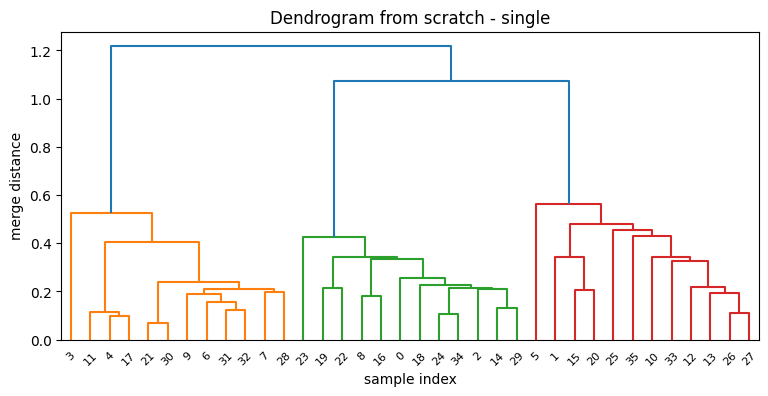

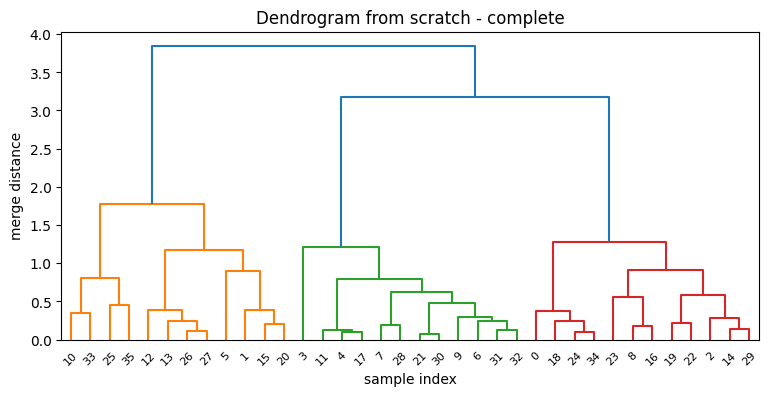

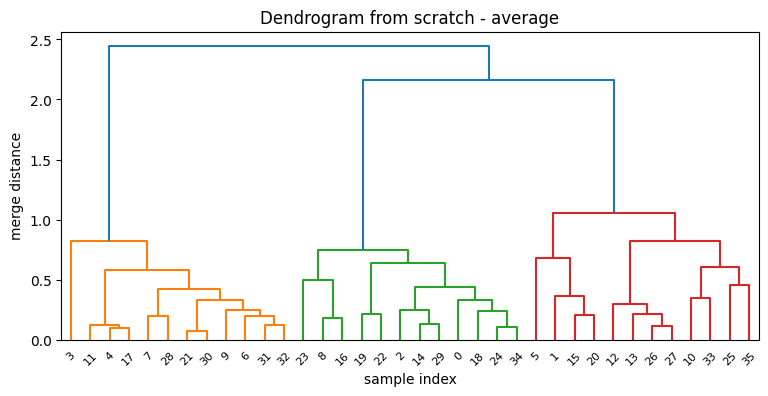

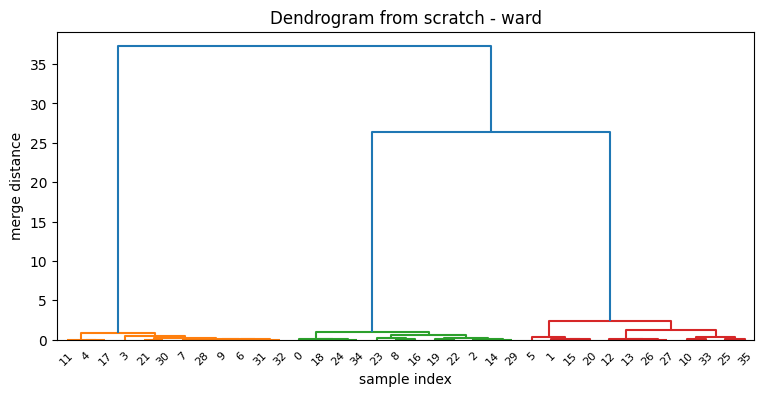

In [ ]:
for linkage in ["single", "complete", "average", "ward"]:
    Z = agglomerative_linkage_matrix(X, linkage=linkage)

    plt.figure(figsize=(9, 4))
    dendrogram(Z, labels=np.arange(len(X)))
    plt.title(f"Dendrogram - {linkage}")
    plt.xlabel("sample index")
    plt.ylabel("merge distance")
    plt.show()

## Visualizacion

In [ ]:
from sklearn.cluster import AgglomerativeClustering

In [ ]:
def sklearn_agglomerative(X, n_clusters=3, linkage="ward", metric="euclidean"):
    model = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage=linkage,
        metric=metric,
        compute_distances=True
    )
    labels = model.fit_predict(X)
    return model, labels

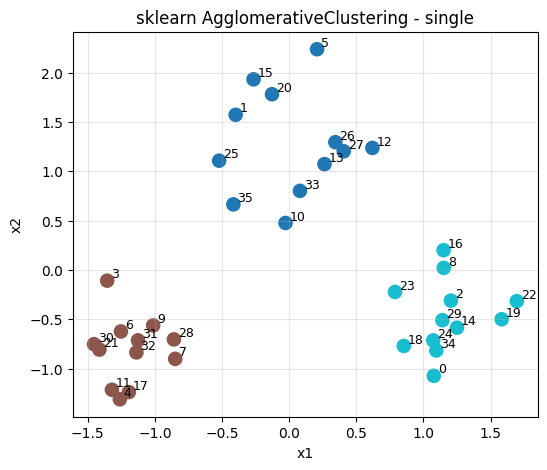

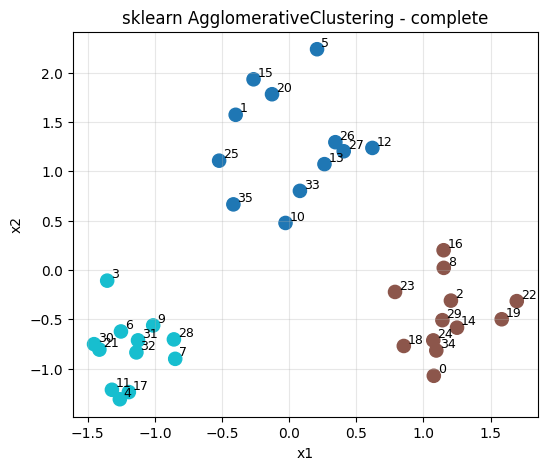

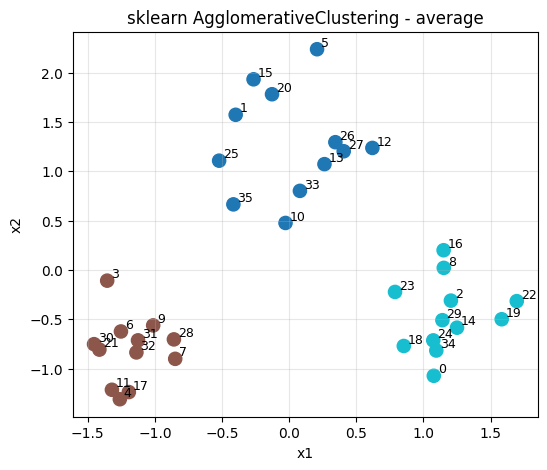

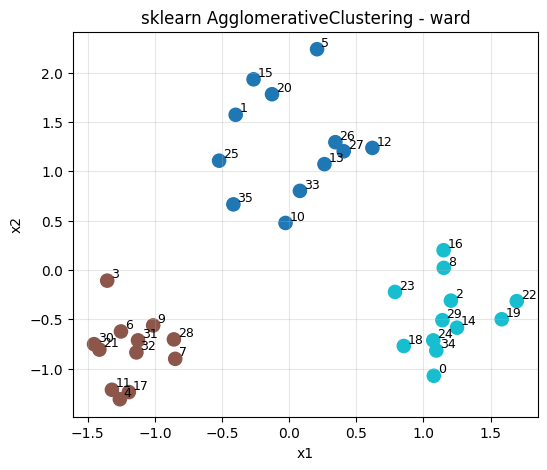

In [ ]:
configs = [
    ("single", "euclidean"),
    ("complete", "euclidean"),
    ("average", "euclidean"),
    ("ward", "euclidean"),
]

for linkage, metric in configs:
    model, labels = sklearn_agglomerative(X, n_clusters=3, linkage=linkage, metric=metric)
    plot_clusters(X, labels, title=f"sklearn AgglomerativeClustering - {linkage}")

## Sklearn

In [ ]:
def sklearn_model_to_linkage_matrix(model):
    n_samples = len(model.labels_)
    counts = np.zeros(model.children_.shape[0], dtype=float)

    for i, merge in enumerate(model.children_):
        count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                count += 1
            else:
                count += counts[child_idx - n_samples]
        counts[i] = count

    Z = np.column_stack([model.children_, model.distances_, counts]).astype(float)
    return Z

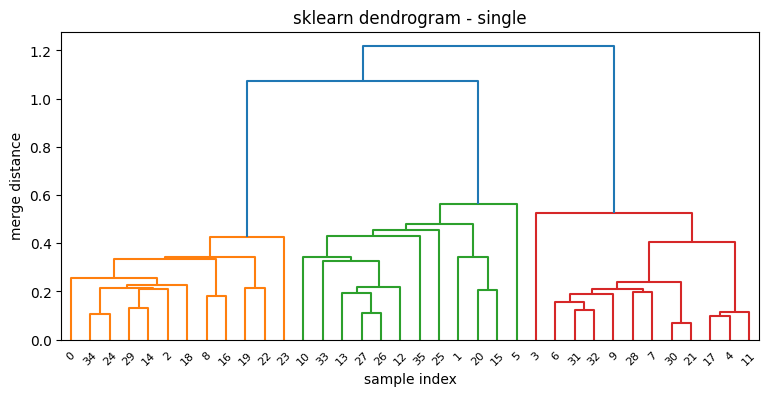

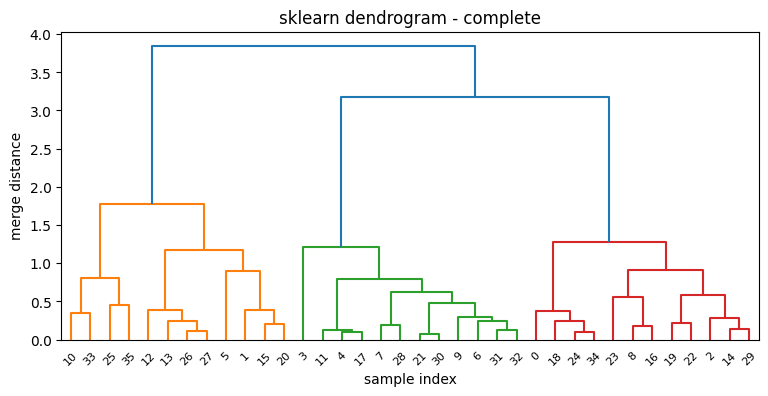

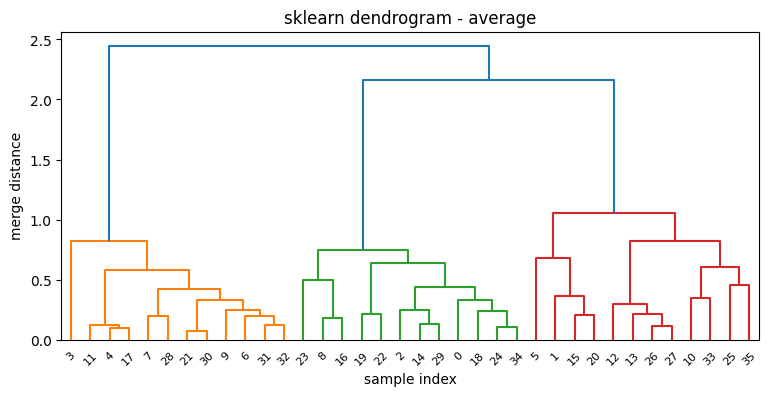

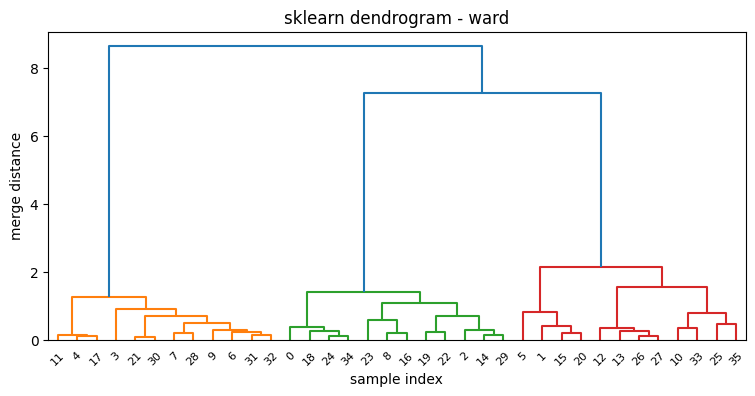

In [ ]:
for linkage, metric in configs:
    model, labels = sklearn_agglomerative(X, n_clusters=3, linkage=linkage, metric=metric)
    Z = sklearn_model_to_linkage_matrix(model)

    plt.figure(figsize=(9, 4))
    dendrogram(Z, labels=np.arange(len(X)))
    plt.title(f"sklearn dendrogram - {linkage}")
    plt.xlabel("sample index")
    plt.ylabel("merge distance")
    plt.show()

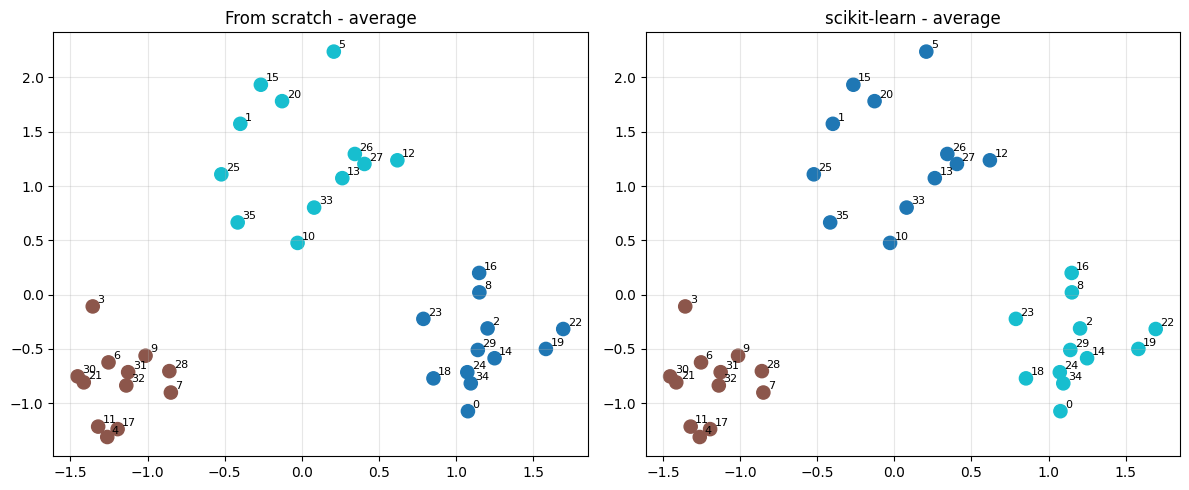

In [ ]:
linkage = "average"

labels_scratch, _ = agglomerative_until_k(X, k=3, linkage=linkage)
model, labels_sklearn = sklearn_agglomerative(X, n_clusters=3, linkage=linkage, metric="euclidean")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=labels_scratch, s=90, cmap="tab10")
axes[0].set_title(f"From scratch - {linkage}")
axes[0].grid(alpha=0.3)

axes[1].scatter(X[:, 0], X[:, 1], c=labels_sklearn, s=90, cmap="tab10")
axes[1].set_title(f"scikit-learn - {linkage}")
axes[1].grid(alpha=0.3)

for ax in axes:
    for i, (x1, x2) in enumerate(X):
        ax.text(x1 + 0.03, x2 + 0.03, str(i), fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
for linkage in ["single", "complete", "average", "ward"]:
    labels, clusters = agglomerative_until_k(X, k=3, linkage=linkage)
    print(f"{linkage:>8} -> {list(map(sorted, clusters))}")

  single -> [[0, 2, 8, 14, 16, 18, 19, 22, 23, 24, 29, 34], [3, 4, 6, 7, 9, 11, 17, 21, 28, 30, 31, 32], [1, 5, 10, 12, 13, 15, 20, 25, 26, 27, 33, 35]]
complete -> [[3, 4, 6, 7, 9, 11, 17, 21, 28, 30, 31, 32], [0, 2, 8, 14, 16, 18, 19, 22, 23, 24, 29, 34], [1, 5, 10, 12, 13, 15, 20, 25, 26, 27, 33, 35]]
 average -> [[0, 2, 8, 14, 16, 18, 19, 22, 23, 24, 29, 34], [3, 4, 6, 7, 9, 11, 17, 21, 28, 30, 31, 32], [1, 5, 10, 12, 13, 15, 20, 25, 26, 27, 33, 35]]
    ward -> [[3, 4, 6, 7, 9, 11, 17, 21, 28, 30, 31, 32], [0, 2, 8, 14, 16, 18, 19, 22, 23, 24, 29, 34], [1, 5, 10, 12, 13, 15, 20, 25, 26, 27, 33, 35]]
